In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from mock_config import CONFIG, FP_FULL
from mock_fp_full_claude import load_fp_catalog, load_spec_data

cosmo = FlatLambdaCDM(H0=100., Om0=0.3151)

In [2]:
spec   = load_spec_data(CONFIG.spec_csv)
d_data = load_fp_catalog(CONFIG.data_fp_full)

02:23:55  INFO      spec : 1835524 → 1835524 entries after cut on zwarn == 0
02:23:56  INFO      FP catalogue : 229842 galaxies total
02:23:56  INFO      FP catalogue : 187395 calibrators kept


In [3]:
print(len(d_data), d_data.columns)

187395 Index(['targetid', 'ra', 'dec', 'zcmb', 'ppxf_vdisp', 'ppxf_vdisp_err',
       'zcmb_group', 'r', 'er', 'i', 'ei', 's', 'es', 'FPcalibrator', 'Sn'],
      dtype='str')


In [4]:
m_data = fits.open(CONFIG.mock_fp_full_data.format(phase=0, real=0))[1].data
#m_rand = fits.open(cfg.mock_fp_clus_rand.format(phase=1))[1].data
m_data.names, m_data.size

(['RA',
  'DEC',
  'ZOBS',
  'ZCOS',
  'vx',
  'vy',
  'vz',
  'r',
  'er',
  's',
  'es',
  'i',
  'ei',
  'Sn',
  'LOGDIST_TRUE',
  'LOGDIST',
  'LOGDIST_ERR',
  'LOGDIST_ALPHA',
  'LOGDIST_CORR',
  'LOGDIST_CORR_ERR',
  'LOGDIST_CORR_ALPHA'],
 156285)

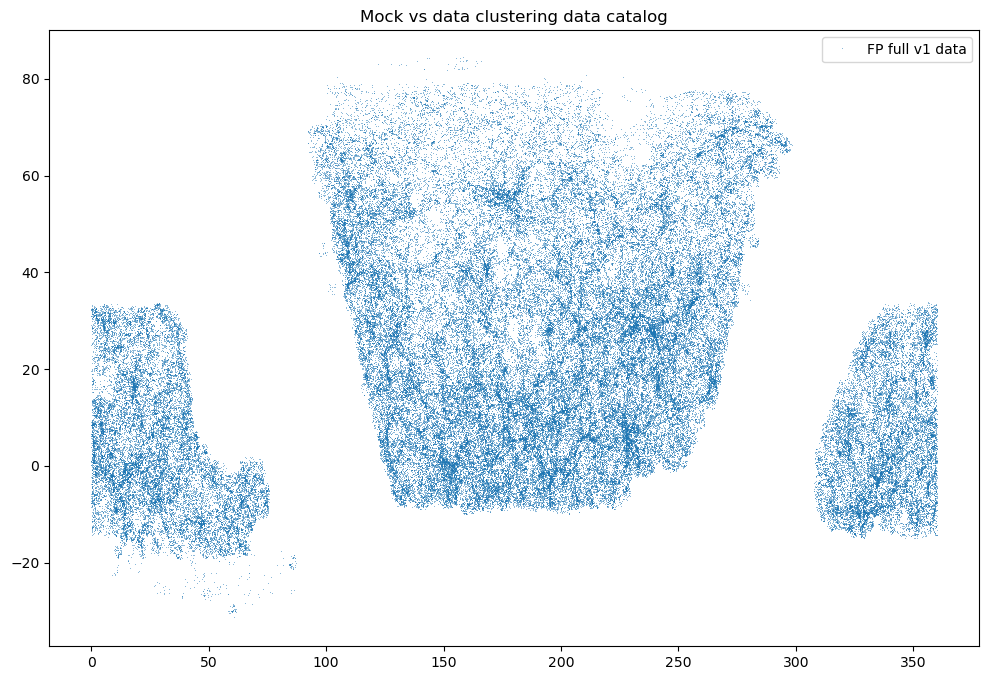

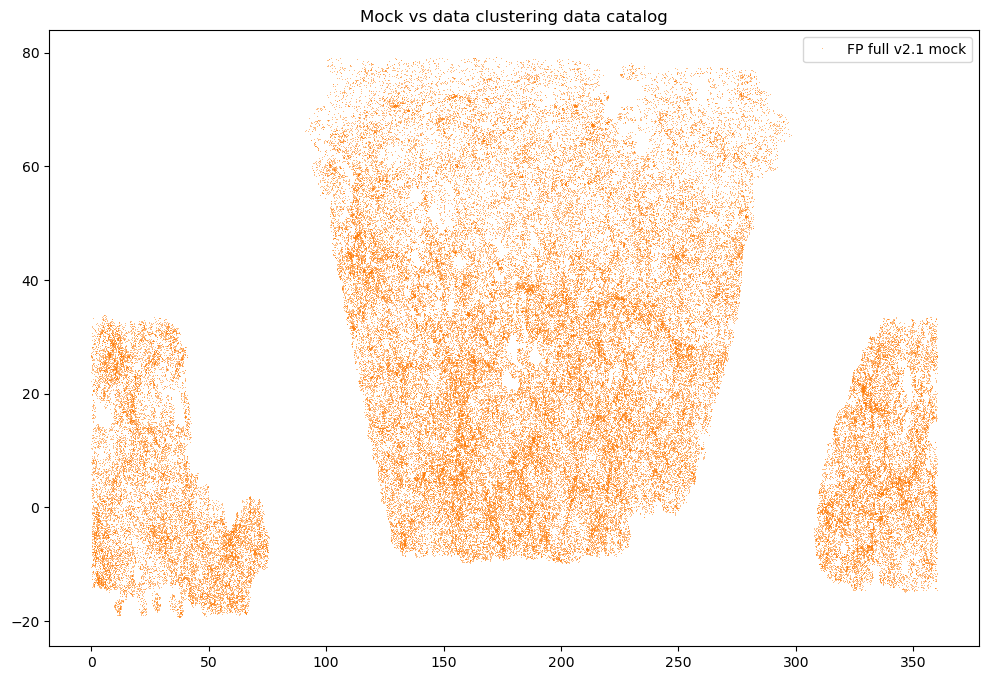

In [5]:
plt.figure(figsize=(12, 8))
plt.plot(d_data['ra'], d_data['dec'], 'C0,', alpha=0.5, label=f'FP full {CONFIG.data_fp_full_version} data')
#plt.plot(m_data['RA'], m_data['DEC'], ',', alpha=0.5, label=f'FP full {CONFIG.version_fp_full} mock')
plt.title('Mock vs data clustering data catalog')
plt.legend()
plt.figure(figsize=(12, 8))
#plt.plot(d_data['ra'], d_data['dec'], ',', alpha=0.5, label=f'FP full {CONFIG.data_fp_full_version} data')
plt.plot(m_data['RA'], m_data['DEC'], 'C1,', alpha=0.5, label=f'FP full {CONFIG.version_fp_full} mock')
plt.title('Mock vs data clustering data catalog')
plt.legend()

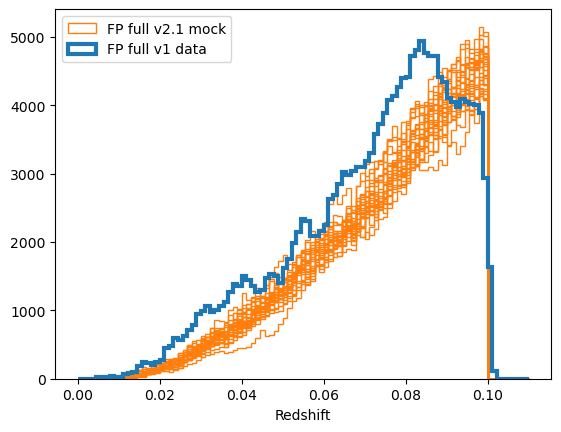

In [6]:
zbins = np.linspace(0, 0.11, 100)
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(CONFIG.mock_fp_full_data.format(phase=phase, real=real))[1].data
        label = f'FP full {CONFIG.version_fp_full} mock' if phase == 0 and real ==0 else None 
        _=plt.hist(m_data_temp['ZOBS'], color='C1', bins=zbins, histtype='step', alpha=1, label=label)
_=plt.hist(d_data['zcmb'], bins=zbins, histtype='step', lw=3,
           label=f'FP full {CONFIG.data_fp_full_version} data')

plt.xlabel('Redshift')
plt.legend()
plt.savefig(f'plots/FP_full_nz_mock_{CONFIG.version_fp_full}_data_{CONFIG.data_fp_full_version}.pdf')